In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import soundfile as sf
import os
import json
import csv
import scipy.signal

# Charger YAMNet
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

def ensure_sample_rate(original_sr, waveform, desired_sr=16000):
    if original_sr != desired_sr:
        desired_len = int(round(len(waveform) * desired_sr / original_sr))
        waveform = scipy.signal.resample(waveform, desired_len)
    return desired_sr, waveform

def extract_embedding(wav_path):
    wav_data, sr = sf.read(wav_path)
    if wav_data.ndim > 1:
        wav_data = np.mean(wav_data, axis=1)
    sr, wav_data = ensure_sample_rate(sr, wav_data)
    _, embeddings, _ = yamnet_model(wav_data)
    return np.mean(embeddings.numpy(), axis=0)  # moyenne temporelle → 1024-D


In [6]:
print(os.listdir("../audios"))

['video1.wav', 'video10.wav', 'video100.wav', 'video1000.wav', 'video1001.wav', 'video1002.wav', 'video1003.wav', 'video1004.wav', 'video1005.wav', 'video1007.wav', 'video1009.wav', 'video1010.wav', 'video1011.wav', 'video1012.wav', 'video1013.wav', 'video1014.wav', 'video1015.wav', 'video1016.wav', 'video1017.wav', 'video1018.wav', 'video1019.wav', 'video102.wav', 'video1020.wav', 'video1021.wav', 'video1022.wav', 'video1023.wav', 'video1024.wav', 'video1025.wav', 'video1026.wav', 'video1027.wav', 'video1028.wav', 'video1029.wav', 'video103.wav', 'video1030.wav', 'video1031.wav', 'video1032.wav', 'video1033.wav', 'video1034.wav', 'video1035.wav', 'video1036.wav', 'video1037.wav', 'video1038.wav', 'video1039.wav', 'video104.wav', 'video1040.wav', 'video1041.wav', 'video1042.wav', 'video1043.wav', 'video1044.wav', 'video1046.wav', 'video1047.wav', 'video1048.wav', 'video1049.wav', 'video105.wav', 'video1050.wav', 'video1051.wav', 'video1052.wav', 'video1053.wav', 'video1054.wav', 'video

In [13]:
# Dossier contenant les vidéos
input_folder = "../audios"
# Dossier où tu veux sauvegarder les fichiers audio
output_folder = "../audios_embeddings"

# Créer le dossier de sortie s’il n’existe pas
os.makedirs(output_folder, exist_ok=True)



# Parcourir toutes les vidéos du dossier
for filename in os.listdir(input_folder):

    wav_path = os.path.join(input_folder, f"{filename}")
    if os.path.exists(wav_path):
        emb = extract_embedding(wav_path)

        out_name = filename[:-3] + "npy"
        out_path = os.path.join(output_folder, out_name)
        np.save(out_path, emb)

In [2]:
# Charger les catégories
category_map = {}
with open("train_val_annotation/category.txt") as f:
    for line in f:
        name, idx = line.strip().split("\t")
        category_map[int(idx)] = name

# Charger le JSON avec les vidéos
with open("train_val_annotation/train_val_videodatainfo.json") as f:
    data = json.load(f)
print("ok")
X, y = [], []
for vid in data["videos"]:
    wav_path = os.path.join("train_val_audios", f"{vid['video_id']}.wav")
    if os.path.exists(wav_path):
        emb = extract_embedding(wav_path)
        X.append(emb)
        y.append(vid["category"])  # catégorie numérique


ok


In [3]:
X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)


(6176, 1024) (6176,)


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)



ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)


num_classes = len(set(y))
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(512, activation='relu', input_shape=(1024,)),
    Dropout(0.6),
    Dense(256, activation='relu'),
    Dropout(0.6),
    Dense(64, activation='relu'),
    Dropout(0.6),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(1e-4, weight_decay=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=37, batch_size=32)


Epoch 1/37


c:\Users\Ali\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


367/367 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.0575 - loss: 3.0477 - val_accuracy: 0.1497 - val_loss: 2.9761
Epoch 2/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.0617 - loss: 2.9961 - val_accuracy: 0.1837 - val_loss: 2.9421
Epoch 3/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0762 - loss: 2.9654 - val_accuracy: 0.1853 - val_loss: 2.9058
Epoch 4/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0906 - loss: 2.9377 - val_accuracy: 0.1982 - val_loss: 2.8578
Epoch 5/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1053 - loss: 2.9099 - val_accuracy: 0.2063 - val_loss: 2.8190
Epoch 6/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1190 - loss: 2.8818 - val_accuracy: 0.2136 - val_loss: 2.7769
Epoch 7/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1270 - loss: 2.8536 - val_accuracy: 0.2241 - val_loss: 2.7395
Epoch 8/37
367/367 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1340 - loss: 2.8325 - val_accuracy: 0.2241 -

In [6]:
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Accuracy : {acc*100:.2f}%")

model.save("yamnet_custom_classifier.h5")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2710 - loss: 2.4394


🎯 Accuracy : 27.10%



✅ Fichiers audio trouvés : 2635
❌ Fichiers manquants : 355

Exemples de fichiers manquants :
test_val_audios\video7013.wav
test_val_audios\video7029.wav
test_val_audios\video7042.wav
test_val_audios\video7073.wav
test_val_audios\video7077.wav
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== Rapport de classification ===
                      precision    recall  f1-score   support

               music       0.37      0.50      0.43       179
              people       0.10      0.19      0.13        69
              gaming       0.24      0.39      0.30       130
      sports/actions       0.59      0.26      0.36       305
news/events/politics       0.20      0.11      0.14       131
           education       0.10      0.52      0.17        62
            tv shows       0.07      0.02      0.03        53
        movie/comedy       0.35      0.05      0.09       262
           animation       0.21      0.36      0.26       100
      vehicles/autos       0.38      0.38      0.38       209

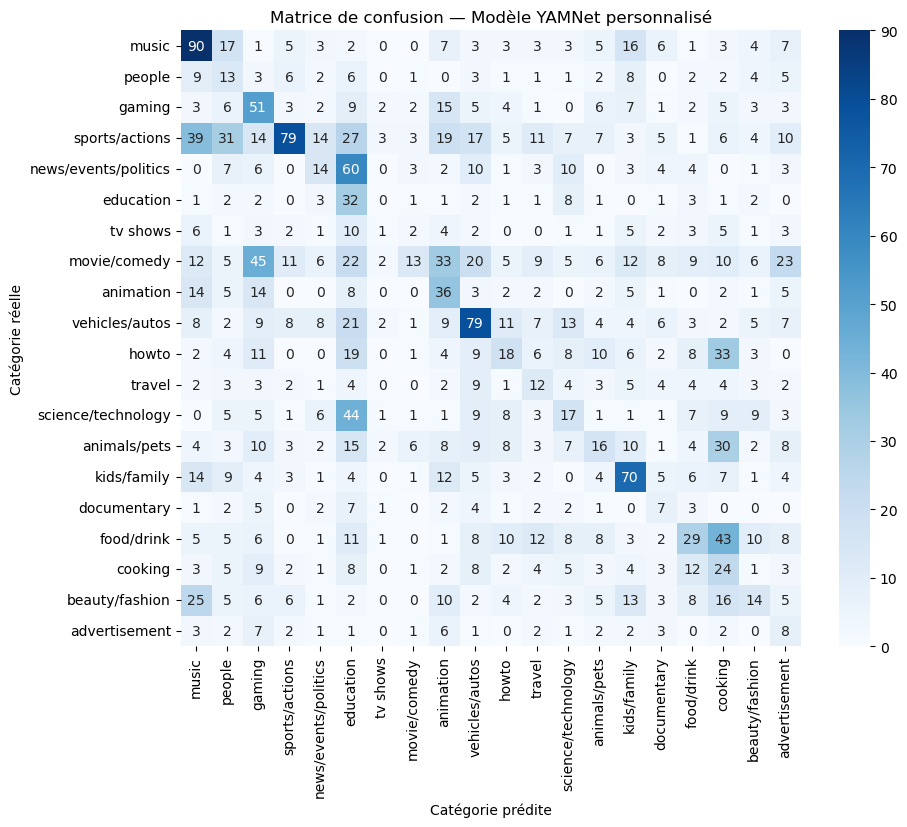

In [7]:
import os
import json
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import soundfile as sf
import scipy.signal
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Charger le modèle personnalisé ===
custom_model = tf.keras.models.load_model("yamnet_custom_classifier.h5")

# === 2. Charger YAMNet ===
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

# === 3. Fonctions utilitaires ===
def ensure_sample_rate(original_sr, waveform, desired_sr=16000):
    """Rééchantillonne le signal si besoin."""
    if original_sr != desired_sr:
        desired_len = int(round(len(waveform) * desired_sr / original_sr))
        waveform = scipy.signal.resample(waveform, desired_len)
    return desired_sr, waveform

def extract_embedding(wav_path):
    """Extrait l’embedding YAMNet moyen pour un fichier audio donné."""
    wav_data, sr = sf.read(wav_path)
    if wav_data.ndim > 1:
        wav_data = np.mean(wav_data, axis=1)
    sr, wav_data = ensure_sample_rate(sr, wav_data)
    _, embeddings, _ = yamnet_model(wav_data)
    return np.mean(embeddings.numpy(), axis=0)

# === 4. Charger les catégories ===
category_map = {}
with open("train_val_annotation/category.txt") as f:
    for line in f:
        name, idx = line.strip().split("\t")
        category_map[int(idx)] = name
inv_category_map = {v: k for k, v in category_map.items()}

# === 5. Charger le JSON de test ===
with open("test_videodatainfo.json/test_videodatainfo.json") as f:
    test_data = json.load(f)

# === 6. Extraire les embeddings et labels ===
X_test, y_test, missing_files = [], [], []

for vid in test_data["videos"]:
    # 🧠 Vérifie le bon champ dans ton JSON :
    # Parfois c’est "video_id", parfois juste "id"
    video_id = vid.get("video_id", vid.get("id"))

    # Chemin du fichier audio
    wav_path = os.path.join("test_val_audios", f"{video_id}.wav")

    if os.path.exists(wav_path):
        emb = extract_embedding(wav_path)
        X_test.append(emb)
        y_test.append(vid["category"])
    else:
        missing_files.append(wav_path)

# === 7. Vérification avant la prédiction ===
print(f"\n✅ Fichiers audio trouvés : {len(X_test)}")
print(f"❌ Fichiers manquants : {len(missing_files)}")

if missing_files:
    print("\nExemples de fichiers manquants :")
    print("\n".join(missing_files[:5]))

if len(X_test) == 0:
    raise ValueError("Aucun fichier audio trouvé — vérifie les chemins et noms de fichiers .wav")

# === 8. Prédiction ===
X_test = np.array(X_test)
y_test = np.array(y_test)

y_pred = custom_model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# === 9. Rapport de performance ===
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred_labels,
      target_names=[category_map[i] for i in sorted(category_map.keys())]))

# === 10. Matrice de confusion ===
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[category_map[i] for i in sorted(category_map.keys())],
            yticklabels=[category_map[i] for i in sorted(category_map.keys())])
plt.xlabel("Catégorie prédite")
plt.ylabel("Catégorie réelle")
plt.title("Matrice de confusion — Modèle YAMNet personnalisé")
plt.show()
